<a href="https://colab.research.google.com/github/virag44/Magassag-elemzes-A.Tina-N.Julia-F.Virag/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math

In [ ]:
def expected_height(m_height,f_height,boy=True):
  if boy==True:
    m=(m_height+f_height+13)/2
    return f'{m}cm a várható magasság, ez azt jelenti hogy a gyerek {m-10}-{m+10} centiméter közötti magas lesz'
  else:
    m=(m_height+f_height-13)/2
    return f'{m}cm a várható magasság, ez azt jelenti hogy a gyerek {m-10}-{m+10} centiméter közötti magas lesz'
expected_height(155,185,False)


'163.5cm a várható magasság, ez azt jelenti hogy a gyerek 153.5-173.5 centiméter közötti magas lesz'

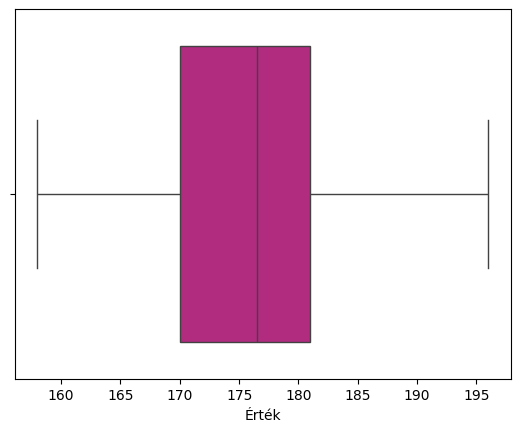

In [ ]:
heights = pd.read_excel('Exatlonheights.xlsx')
sns.boxplot(x='Érték', data=heights, color='mediumvioletred')
plt.show()

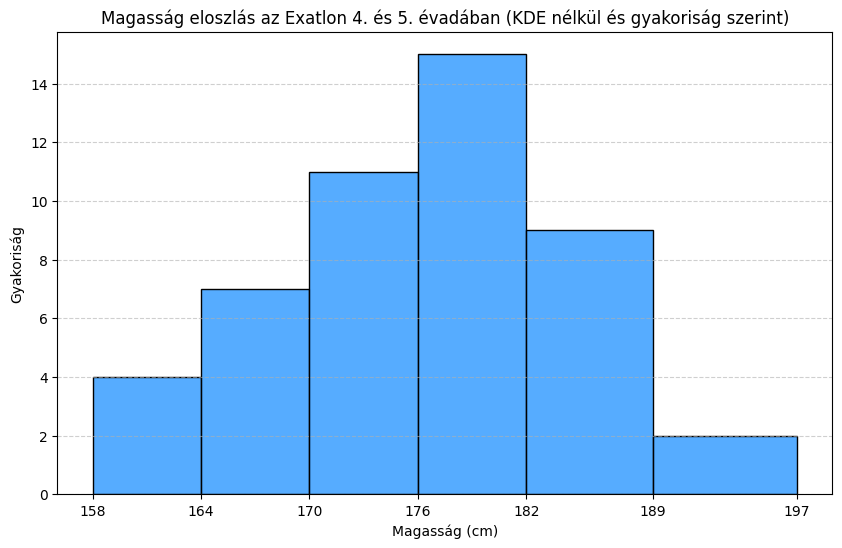

In [ ]:
borders=[158, 164, 170, 176, 182, 189, 197]
plt.figure(figsize=(10, 6))
sns.histplot(data=heights, x='Érték', bins=borders, color='dodgerblue', edgecolor='black')
plt.title('Magasság eloszlás az Exatlon 4. és 5. évadában (KDE nélkül és gyakoriság szerint)')
plt.xlabel('Magasság (cm)')
plt.ylabel('Gyakoriság')
plt.xticks(borders)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

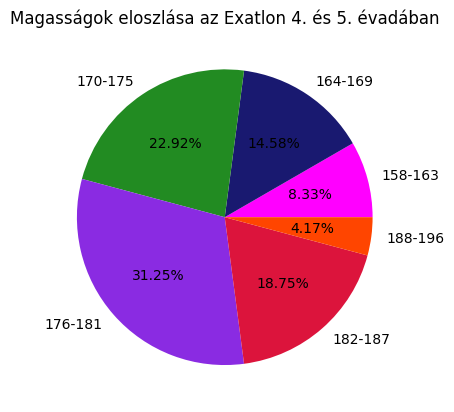

In [ ]:
counts, _ = np.histogram(heights['Érték'], bins=borders)
frequency = counts
groups=["158-163","164-169","170-175","176-181","182-187","188-196"]
colours=["fuchsia","midnightblue","forestgreen", "blueviolet", "crimson","orangered"]
plt.pie(frequency, labels=groups, colors=colours, autopct='%1.2f%%')
plt.title("Magasságok eloszlása az Exatlon 4. és 5. évadában")
plt.show()

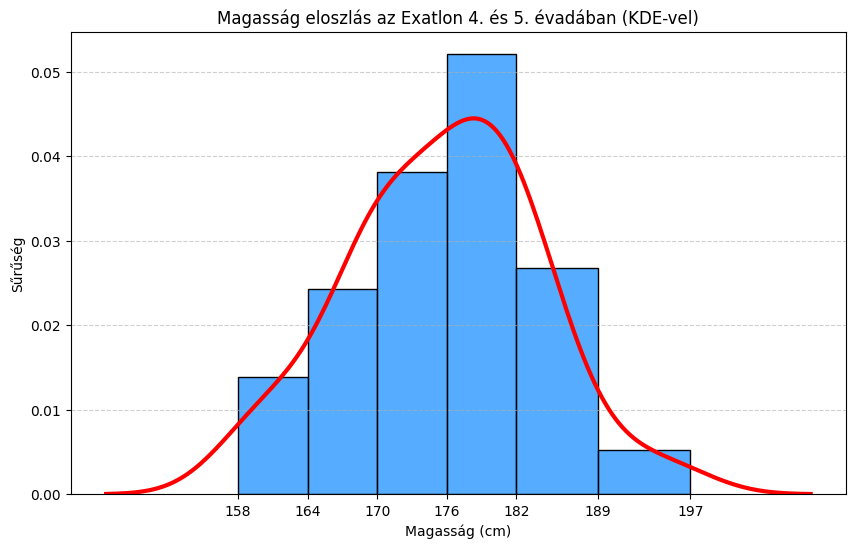

In [ ]:
borders=[158, 164, 170, 176, 182, 189, 197]
plt.figure(figsize=(10, 6))
sns.histplot(data=heights, x='Érték', bins=borders, color='dodgerblue', edgecolor='black', kde=False, stat='density')
sns.kdeplot(data=heights, x='Érték', color='red', linewidth=3, ax=plt.gca())
plt.title('Magasság eloszlás az Exatlon 4. és 5. évadában (KDE-vel)')
plt.xlabel('Magasság (cm)')
plt.ylabel('Sűrűség')
plt.xticks(borders)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

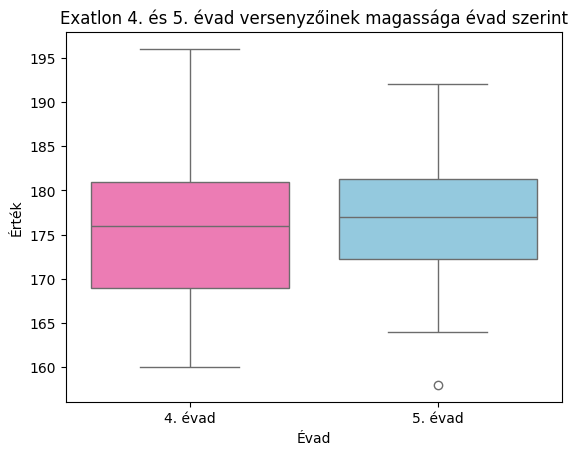

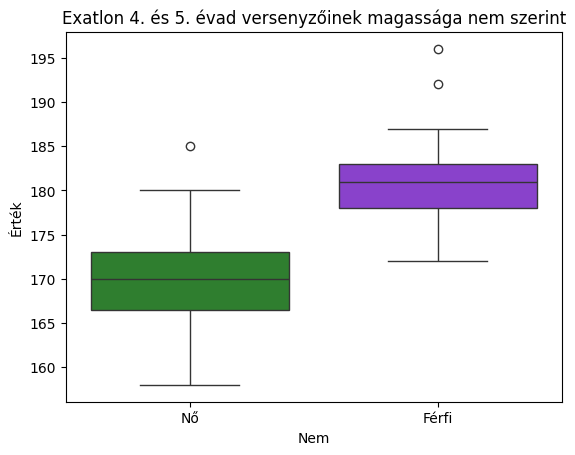

In [ ]:
sns.boxplot(x='Évad', y='Érték', hue='Évad', data=heights, legend=False, palette=['hotpink', 'skyblue'] )
plt.title("Exatlon 4. és 5. évad versenyzőinek magassága évad szerint")
plt.show()
sns.boxplot(x='Nem', y='Érték', hue='Nem', data=heights, legend=False, palette=['forestgreen', 'blueviolet'])
plt.title("Exatlon 4. és 5. évad versenyzőinek magassága nem szerint")
plt.show()




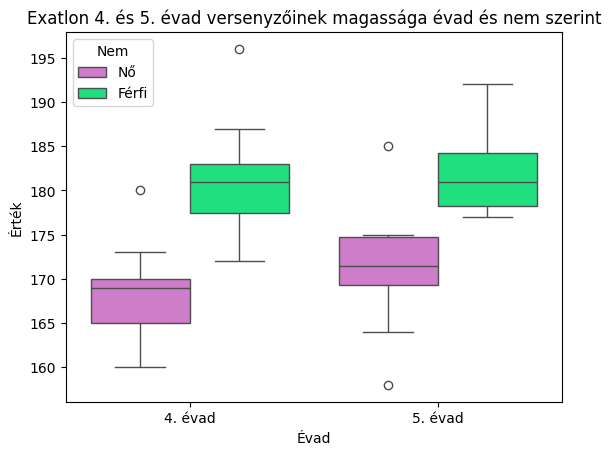

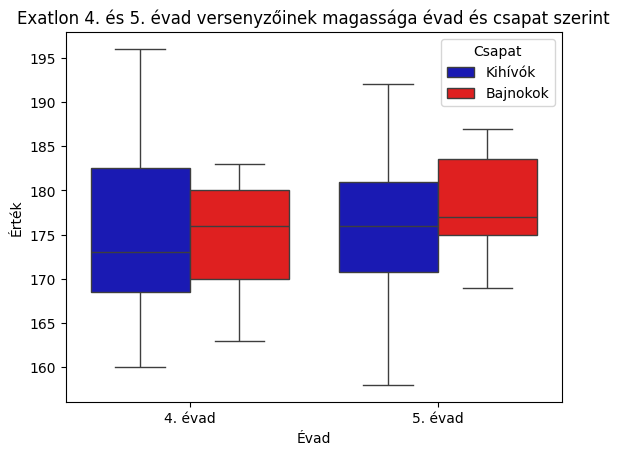

In [ ]:
sns.boxplot(x='Évad', y='Érték', hue='Nem', data=heights, palette=['orchid', 'springgreen'] )
plt.title("Exatlon 4. és 5. évad versenyzőinek magassága évad és nem szerint")
plt.show()
sns.boxplot(x='Évad', y='Érték', hue='Csapat', data=heights, palette=['mediumblue', 'red'] )
plt.title("Exatlon 4. és 5. évad versenyzőinek magassága évad és csapat szerint")
plt.show()

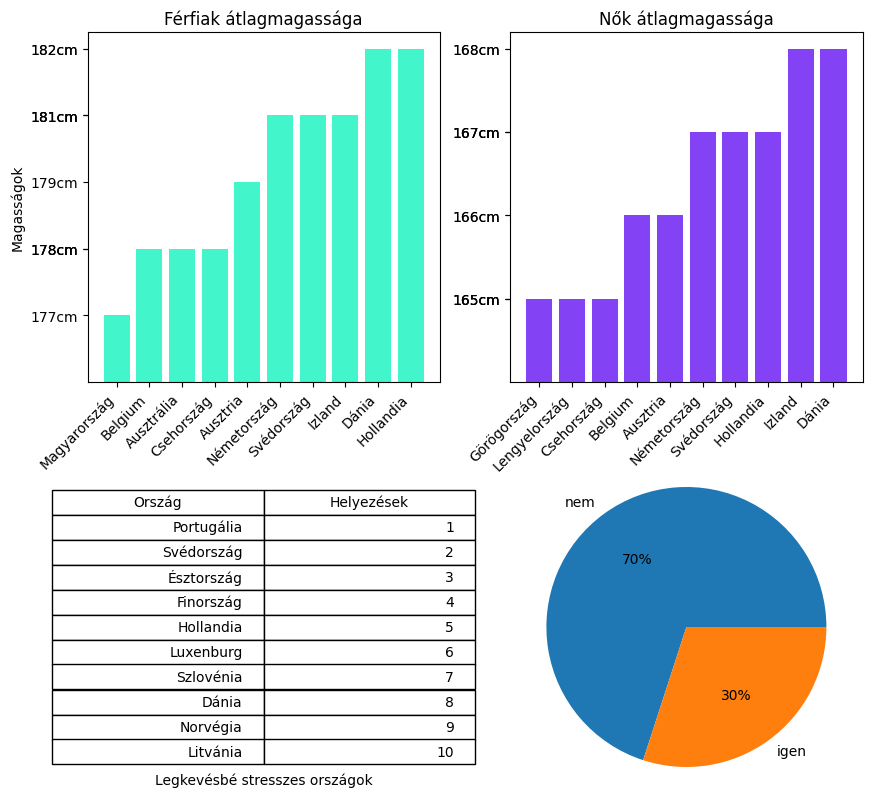

In [3]:
x_labels = []
y_labels = []
y = []

with open("Top10-tallest-men.txt", "r") as file:
    for line in file:
        line = line.strip()

        if line.count(",") == 2:
            orszag, magasag, y_ertek = line.split(',')

            x_labels.append(orszag)
            y_labels.append(magasag)
            y.append(int(y_ertek))


x_labels2 = []
y_labels2 = []
y2 = []

with open("Top10-tallest-women.txt", "r") as file:
    for line in file:
        line = line.strip()

        if line.count(",") == 2:
            orszag, magassag, y_ertek = line.split(',')

            x_labels2.append(orszag)
            y_labels2.append(magassag)
            y2.append(int(y_ertek))


x_labels3 = []
y3 = []

with open("Least-stressed.txt", "r") as file:
  for line in file:
    line = line.strip()
    orszag, y_ertek = line.split(',')

    x_labels3.append(orszag)
    y3.append(int(y_ertek))


fig, axs = plt.subplots(2, 2, figsize=(10, 10))

x = np.arange(len(y))

axs[0,0].bar(x, y, color='#42f5cb')
axs[0,0].set_xticks(x)
axs[0,0].set_xticklabels(x_labels, rotation=45, ha='right')
axs[0,0].set_yticks(y)
axs[0,0].set_yticklabels(y_labels)
axs[0,0].set_title("Férfiak átlagmagassága")
axs[0,0].set_ylabel('Magasságok')




x2 = np.arange(len(y2))

axs[0,1].bar(x, y2, color='#8442f5')
axs[0,1].set_xticks(x)
axs[0,1].set_xticklabels(x_labels2, rotation=45, ha='right')
axs[0,1].set_yticks(y2)
axs[0,1].set_yticklabels(y_labels2)
axs[0,1].set_title("Nők átlagmagassága")

df = pd.DataFrame({"Ország": x_labels3,"Helyezések": y3})

axs[1,0].axis('off')

table = axs[1,0].table(cellText=df.values,colLabels=df.columns,loc='center')

table.scale(1.2, 1.5)

axs[1,0].text(0.5, 0.05, "Legkevésbé stresszes országok", ha='center')



labels_k= ['nem', 'igen']
sizes = [70,30 ]

_=axs[1, 1].pie(sizes, labels=labels_k, autopct= '%1.0f%%')

In [5]:

def welch_test(x1, x2):
    n1 = len(x1)
    n2 = len(x2)

    atlag1 = sum(x1) / n1
    atlag2 = sum(x2) / n2

    szn1 = sum((x - atlag1)**2 for x in x1) / (n1 - 1)
    szn2 = sum((x - atlag2)**2 for x in x2) / (n2 - 1)

    ab = math.sqrt(szn1/n1 + szn2/n2)

    t = (atlag1 - atlag2) / ab

    d = ((szn1/n1 + szn2/n2)**2) / (
        ((szn1/n1)**2 / (n1-1)) +
        ((szn2/n2)**2 / (n2-1)))

    return t, d


ferfi = [int(x.replace("cm", "")) for x in y_labels]
no = [int(x.replace("cm", "")) for x in y_labels2]
welch_test(ferfi,no)


(19.14138248310412, 15.294789965860174)

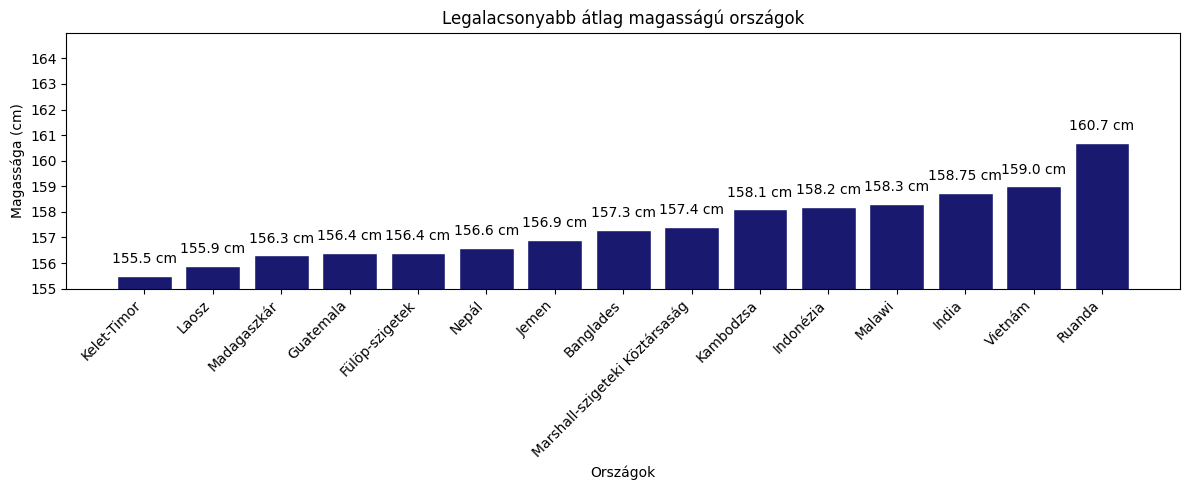

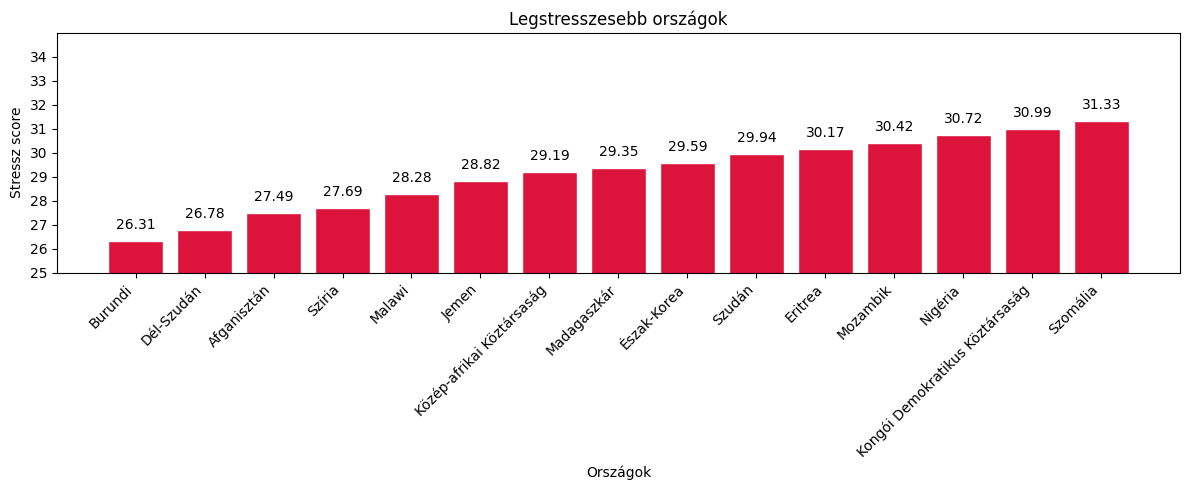

In [ ]:
countries = []
heights = []

with open("Top15-shortest.txt", "r") as file:
    for line in file:
        country, height = line.strip().split(",")
        height = float(height.strip().replace("cm", ""))
        countries.append(country)
        heights.append(height)

x = range(len(countries))
plt.figure(figsize=(12,5))
plt.bar(x, heights, facecolor='midnightblue', edgecolor='white')
plt.ylim(155, 165)
plt.xticks(x, countries, rotation=45, ha='right')
plt.yticks(range(155, 165, 1))

for i in range(len(countries)):
    plt.text(x[i], heights[i] + 0.5,
             str(heights[i]) + " cm",
             ha='center')

plt.xlabel('Országok')
plt.ylabel('Magassága (cm)')
plt.title('Legalacsonyabb átlag magasságú országok')
plt.tight_layout()
plt.show()

countries = []
stressscores = []

with open("Most-stressed.txt", "r") as file:
    for line in file:
        country, stressscore = line.strip().split(',')
        countries.append(country)
        stressscores.append(float(stressscore))

x = range(len(countries))
plt.figure(figsize=(12,5))
plt.bar(x, stressscores, facecolor='crimson', edgecolor='white')
plt.ylim(25,35)
plt.xticks(x, countries, rotation=45, ha='right')
plt.yticks(range(25,35,1))
for i in range(len(countries)):
    plt.text(x[i], stressscores[i] + 0.5,
             str(stressscores[i]),
             ha='center')
plt.xlabel('Országok')
plt.ylabel('Stressz score')
plt.title('Legstresszesebb országok')
plt.tight_layout()
plt.show()

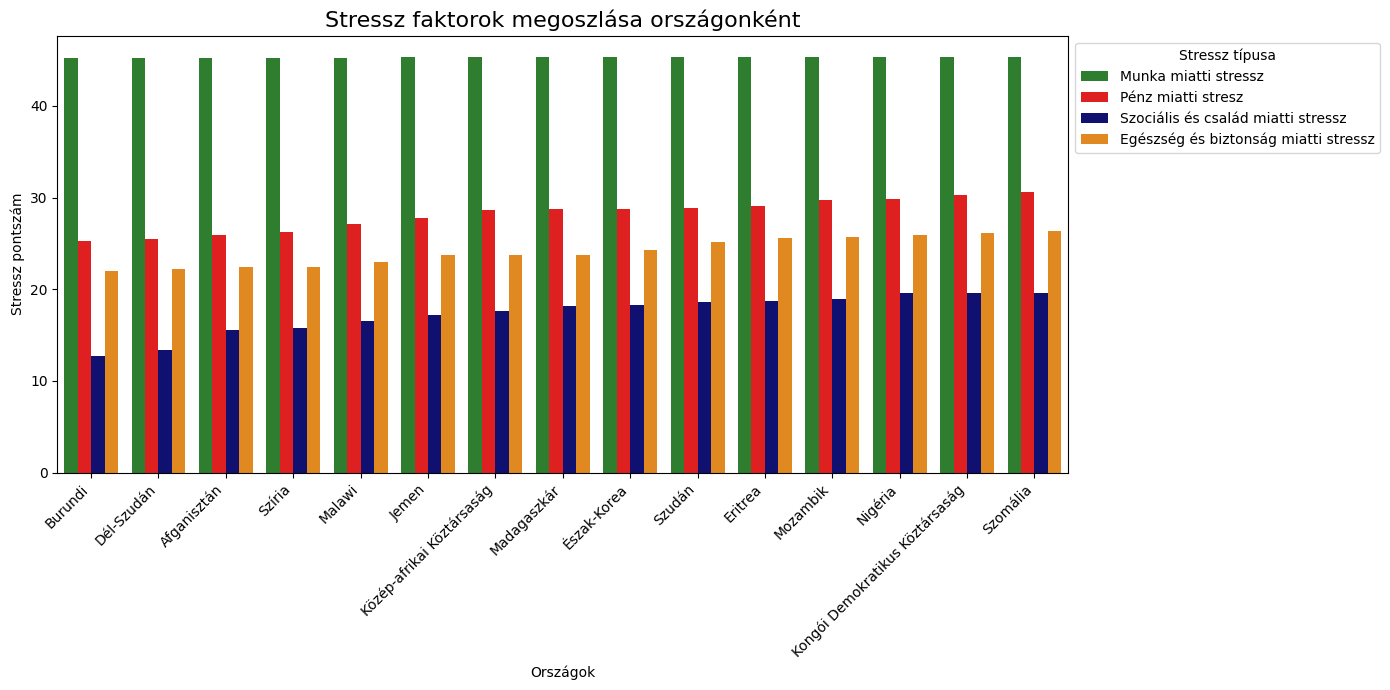

In [ ]:
stress = pd.read_excel("Stressz-pontszamok.xlsx")
plt.figure(figsize=(14, 7))
sns.barplot(data=stress, x="Országok", y="Stressz pontszám",hue="Stressz típusa",palette=['forestgreen', 'red', 'navy', 'darkorange'])
plt.xticks(rotation=45, ha="right")
plt.title("Stressz faktorok megoszlása országonként", fontsize=16)
plt.xlabel("Országok")
plt.ylabel("Stressz pontszám")
plt.legend(title="Stressz típusa", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
heights = {}
stressscore = {}

with open("Top15-shortest.txt", "r") as file:
    for line in file:
        country, height = line.strip().split(",")
        height = float(height.strip().replace("cm", ""))
        heights[country] = height

with open("Most-stressed.txt", "r") as file:
    for line in file:
        country, stress = line.strip().split(",")
        stress = float(stress.strip())
        stressscore[country] = stress

kozos_orszagok = []

for country in heights:
    if country in stressscore:
        kozos_orszagok.append(country)

data = []
for country in kozos_orszagok:
    data.append([country, heights[country],stressscore[country]])
df = pd.DataFrame(data, columns=["Országok","Átlagos magasság(cm)","Stressz Score"])
print("Országok amik mindkettőben szerepelnek")
print(df)

Országok amik mindkettőben szerepelnek
      Országok  Átlagos magasság(cm)  Stressz Score
0  Madagaszkár                 156.3          29.35
1        Jemen                 156.9          28.82
2       Malawi                 158.3          28.28
